# Trabajo practico 1. Vision por computadora

Integrantes: 
- Barquinero, Mauro
- Campos, Mariano
- Jose
- Ojeda, Juan

## Parte 1 (imágenes en /white_patch):
1. Implementar el algoritmo White Patch para librarnos de las diferencias de color de iluminación.
2. Mostrar los resultados obtenidos y analizar las posibles fallas (si es que las hay) en el caso de White patch.

Procesando: test_blue.png


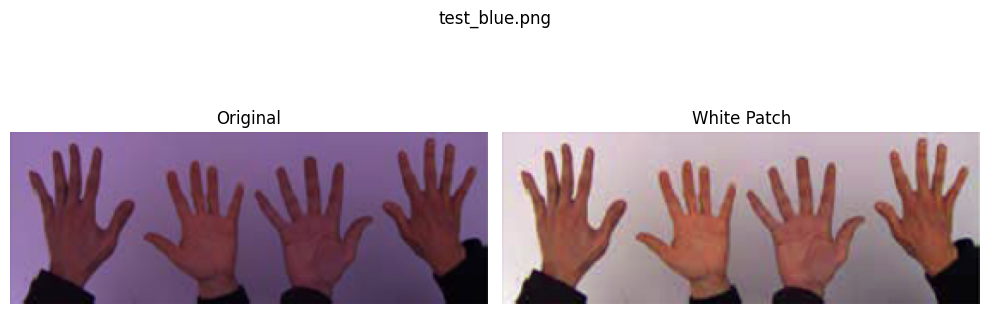

Procesando: test_green.png


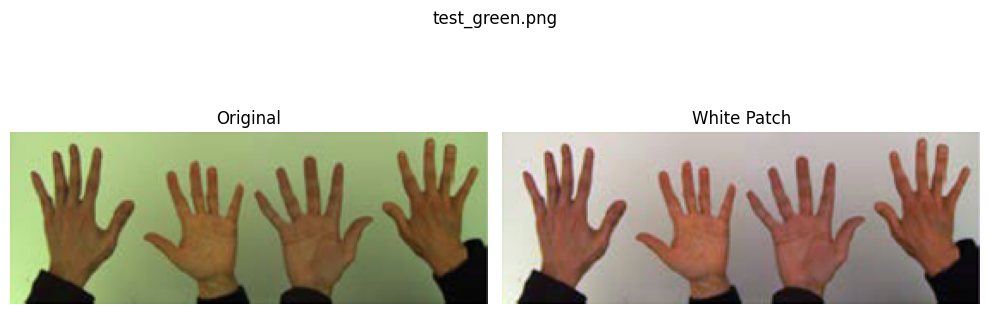

Procesando: test_red.png


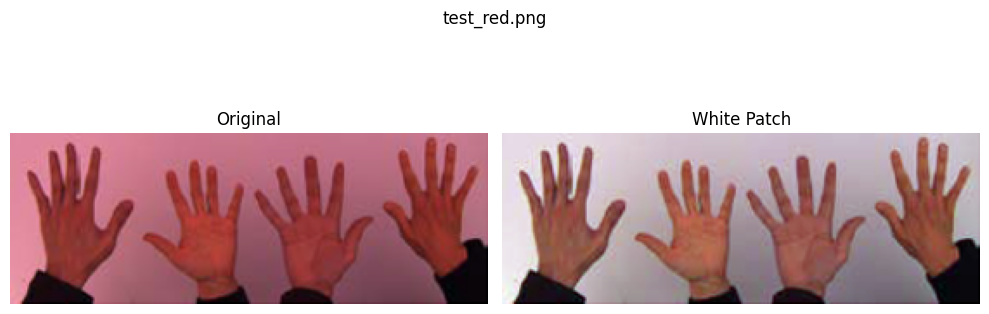

Procesando: wp_blue.jpg


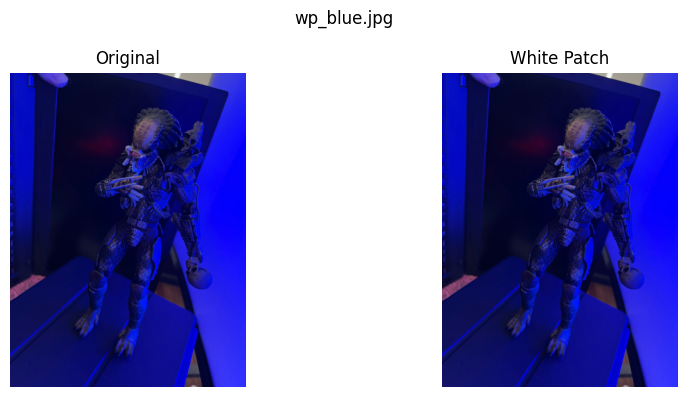

Procesando: wp_green.png


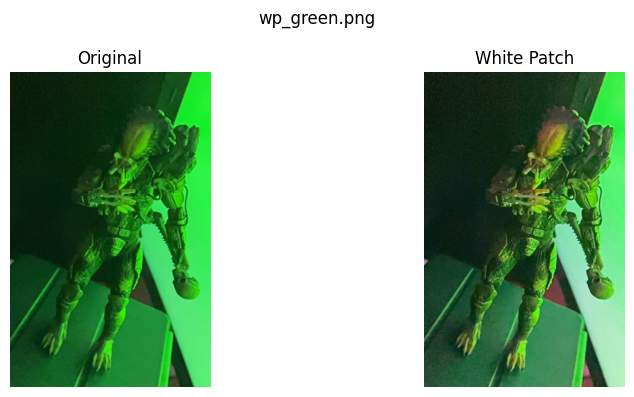

Procesando: wp_green2.jpg


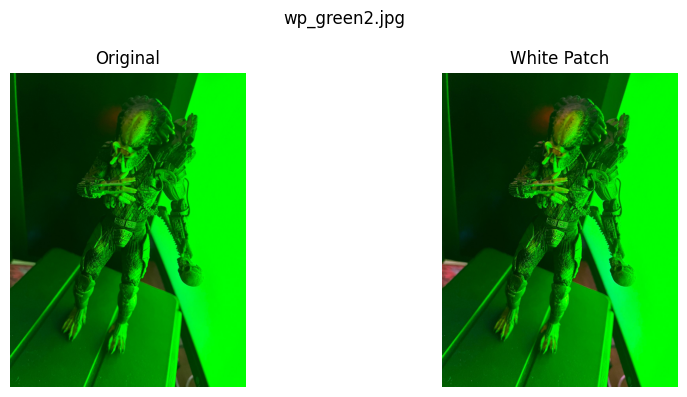

Procesando: wp_red.png


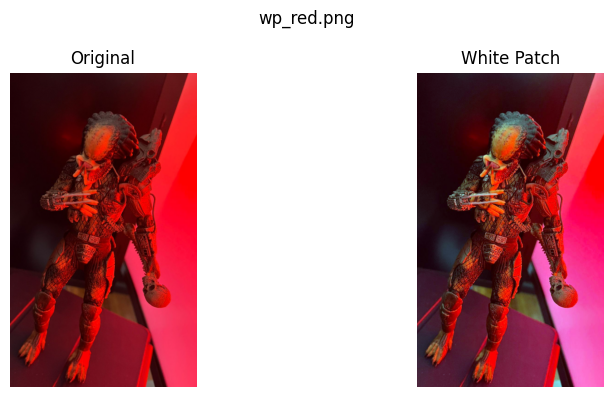

Procesando: wp_red2.jpg


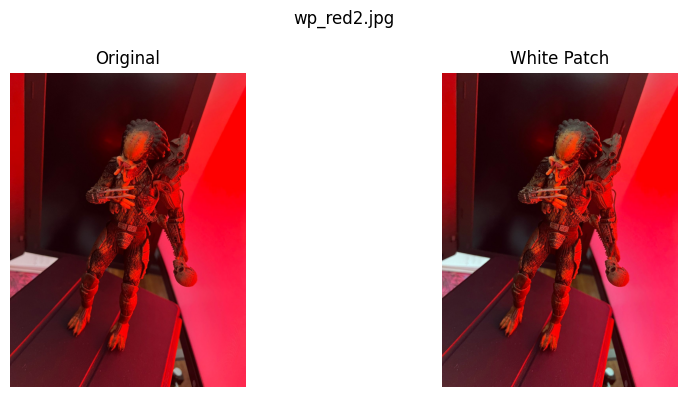

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os


def white_patch(image):
    """
    Aplica el algoritmo White Patch a una imagen para la corrección de color.

    El algoritmo White Patch normaliza los canales de color de la imagen
    escalándolos en función del valor máximo de intensidad en cada canal. Esto
    mejora la imagen corrigiendo los desequilibrios de color.

    Parámetro:
        image (numpy.ndarray): La imagen de entrada como un array de NumPy con forma (H, W, C),
                            donde H es la altura, W es el ancho y C es el número
                            de canales de color (por ejemplo, 3 para RGB).

    Devuelve:
        numpy.ndarray: La imagen corregida en color como un array de NumPy con la misma forma
                    que la imagen de entrada. Los valores de los píxeles se recortan al rango
                    [0, 255] y se convierten a uint8.

    Notas:
        - Si un canal de color tiene un valor máximo de 0, se reemplaza por 1 para evitar
        la división por cero.
        - El algoritmo asume que la imagen de entrada está en formato de punto flotante antes
        del procesamiento y la convierte de nuevo a uint8 después de la corrección.
    """
    image = image.astype(np.float32)
    max_vals = np.max(image, axis=(0, 1))
    max_vals[max_vals == 0] = 1  # Evitar división por cero
    corrected = (image / max_vals) * 255.0
    corrected = np.clip(corrected, 0, 255).astype(np.uint8)
    return corrected

# Carpetas de entrada/salida
input_folder = "vision_computadora_I/Material_TPs/TP1/white_patch"
output_folder = "white_patch_resultados"
os.makedirs(output_folder, exist_ok=True)

# Procesar todas las imágenes de la carpeta
for filename in os.listdir(input_folder):
    if filename.lower().endswith((".png", ".jpg", ".jpeg")):
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, f"fixed_{filename}")

        print(f"Procesando: {filename}")

        img = cv2.imread(input_path)
        corrected = white_patch(img)
        cv2.imwrite(output_path, corrected)

        # Mostrar comparación
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        corrected_rgb = cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 4))
        plt.suptitle(filename)
        plt.subplot(1, 2, 1)
        plt.title("Original")
        plt.imshow(img_rgb)
        plt.axis("off")
        plt.subplot(1, 2, 2)
        plt.title("White Patch")
        plt.imshow(corrected_rgb)
        plt.axis("off")
        plt.tight_layout()
        plt.show()


## Análisis del algoritmo White Patch

El algoritmo **White Patch** busca corregir dominancias de color normalizando cada canal RGB con respecto al valor máximo presente en dicho canal. Esto se hace bajo la suposición de que en la escena existe un píxel que representa un blanco puro o una superficie neutra.

### Fórmula utilizada:

Para cada canal $c \in \{R, G, B\}$, se aplica:

$$I'_c(x, y) = \frac{I_c(x, y)}{\max(I_c)} \cdot 255$$

Donde:
- $I_c(x, y)$ es el valor del canal $c$ en el píxel $(x, y)$,
- $\max(I_c)$ es el valor máximo encontrado en ese canal en toda la imagen.

---

### Análisis de fallas

En imágenes donde toda la iluminación está dominada por un solo canal (por ejemplo, rojo), se observan los siguientes comportamientos:

- El canal dominante (ej. rojo) ya tiene $\max(R) \approx 255$, por lo tanto:

$$I'_R(x, y) \approx \frac{I_R(x, y)}{255} \cdot 255 = I_R(x, y)$$

**No hay cambio alguno**.

- Los canales secundarios (ej. verde y azul) tienen valores bajos. Por ejemplo, si $\max(G) = 20$, entonces:

$$
I'_G(x, y) = \frac{I_G(x, y)}{20} \cdot 255
$$

Se amplifican valores bajos o ruidosos, **sin aportar información real de color**.

---

### Conclusión

El algoritmo White Patch depende fuertemente de la existencia de un píxel blanco o neutro en la imagen. En escenas con iluminación monocromática (solo roja, verde o azul), no hay información suficiente en los canales secundarios para realizar una corrección efectiva. Esto limita severamente su utilidad en ese tipo de imágenes.



## Parte 2:

1. Para las imágenes img1_tp.png y img2_tp.png leerlas con OpenCV en escala de grisas y 
visualizarlas. 
2. Elija el numero de bins que crea conveniente y grafique su histograma, compare los histogramas entre si. Explicar lo que se observa, si tuviera que entrenar un modelo de clasificación/detección de imágenes, considera que puede ser de utilidad tomar como ‘features’ a los histogramas?

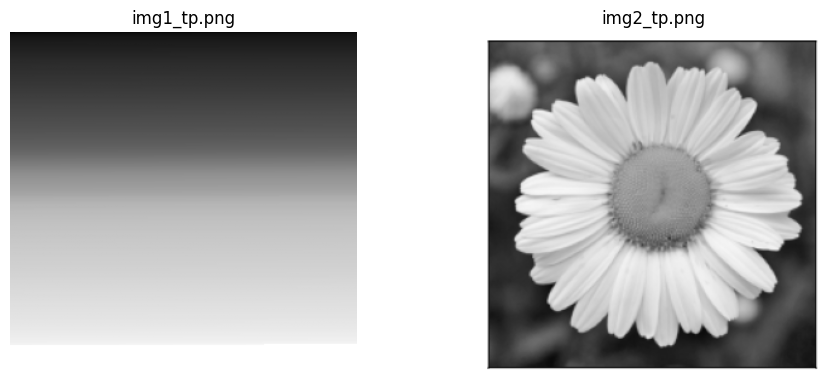

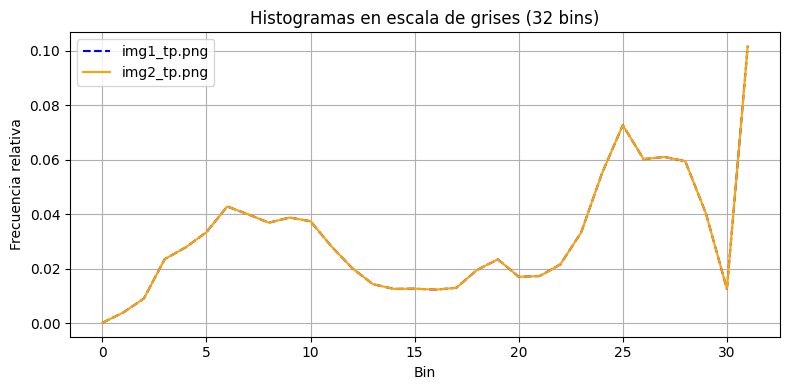

In [18]:
# Rutas a las imágenes
img1 = cv2.imread("vision_computadora_I/Material_TPs/TP1/img1_tp.png", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("vision_computadora_I/Material_TPs/TP1/img2_tp.png", cv2.IMREAD_GRAYSCALE)

# Mostrar imágenes
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("img1_tp.png")
plt.imshow(img1, cmap='gray')
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("img2_tp.png")
plt.imshow(img2, cmap='gray')
plt.axis("off")
plt.tight_layout()
plt.show()

# Parámetros del histograma
bins = 32

# Calcular y normalizar histogramas
hist1 = cv2.calcHist([img1], [0], None, [bins], [0, 256])
hist2 = cv2.calcHist([img2], [0], None, [bins], [0, 256])
hist1 /= hist1.sum()
hist2 /= hist2.sum()

# Mostrar histogramas
plt.figure(figsize=(8, 4))
plt.plot(hist1, label="img1_tp.png", linestyle='--', color='blue')
plt.plot(hist2, label="img2_tp.png", linestyle='-', color='orange')
plt.title(f"Histogramas en escala de grises ({bins} bins)")
plt.xlabel("Bin")
plt.ylabel("Frecuencia relativa")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Análisis de histogramas en escala de grises

Las imágenes `img1_tp.png` e `img2_tp.png` fueron convertidas a escala de grises y se calcularon sus histogramas con 32 bins. Al graficarlos de manera superpuesta, se observó que los histogramas son prácticamente idénticos en forma y frecuencia relativa.

### Conclusión

Esto indica que ambas imágenes comparten una distribución de intensidades de grises muy similar, lo que sugiere que:

- Su contenido visual general (luminosidad, contraste y texturas globales) es muy parecido.
- El histograma en escala de grises **no logra capturar diferencias relevantes entre las imágenes** (si es que existen).

### ¿Sirven como features?

En este caso, los histogramas en escala de grises **no resultan útiles como features discriminativos**, ya que ambas imágenes presentan distribuciones prácticamente idénticas, a pesar de que podrían contener diferencias estructurales. Esto evidencia que este tipo de descriptor, si bien es sencillo y rápido de calcular, **no es adecuado como única fuente de información para tareas de clasificación o detección de objetos**, especialmente cuando se requiere distinguir contenido visual más complejo.
